In [14]:
from google.colab import drive
drive.mount('/content/drive')

import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

# Đường dẫn đến thư mục chứa dữ liệu trên Google Drive
data_dir = '/content/drive/MyDrive/Data_Flower'

# Thiết lập kích thước ảnh và kích thước lô
img_height = 180
img_width = 180
batch_size = 32



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# Tải tập dữ liệu huấn luyện (Training Data)
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2, # Chia 20% dữ liệu để xác thực
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

# Tải tập dữ liệu xác thực (Validation Data)
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

# Lấy danh sách tên các loài hoa từ thư mục
class_names = train_ds.class_names
print(f"Các loại hoa được nhận diện: {class_names}")

# Tối ưu hóa hiệu năng đọc dữ liệu khi huấn luyện
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 1724 files belonging to 5 classes.
Using 1380 files for training.
Found 1724 files belonging to 5 classes.
Using 344 files for validation.
Các loại hoa được nhận diện: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


=== CẤU TRÚC MÔ HÌNH ===


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 180, 180, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 22, 22, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 15488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,982,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,080,677 (7.94 MB)

 Trainable params: 2,080,677 (7.94 MB)

 Non-trainable params: 0 (0.00 B)


Bắt đầu huấn luyện mô hình với 100 epochs...
Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.3486 - loss: 1.4768 - val_accuracy: 0.4651 - val_loss: 1.2649
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5036 - loss: 1.1794 - val_accuracy: 0.5581 - val_loss: 1.0711
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5725 - loss: 1.0622 - val_accuracy: 0.6541 - val_loss: 0.9640
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6297 - loss: 0.9754 - val_accuracy: 0.6105 - val_loss: 0.9930
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6688 - loss: 0.8444 - val_accuracy: 0.6948 - val_loss: 0.8665
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6942 - loss: 0.8050 - val_accuracy: 0.6279 - val_loss: 1.1218
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.6971 - loss: 0.7820 - val_accuracy: 0.6424 - val_loss: 0.9845
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - acc

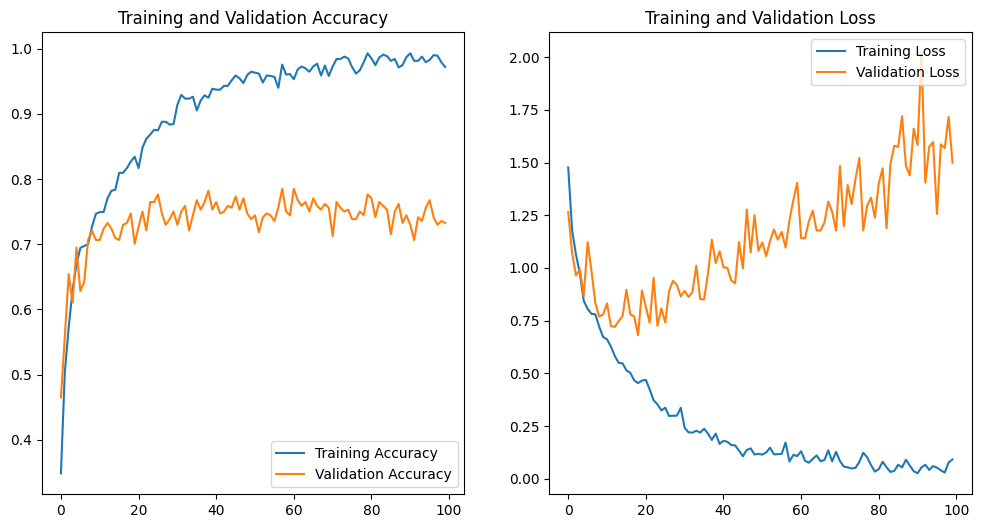

In [16]:
num_classes = len(class_names)

# Xây dựng mô hình
model = models.Sequential([
  # Khối Data Augmentation (Tăng cường dữ liệu)
  layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),

  # Khối Rescaling (Chuẩn hóa giá trị pixel về dải [0, 1])
  layers.Rescaling(1./255),

  # Các lớp Convolutional và MaxPooling
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(128, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  # Khối phân loại (Fully Connected)
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

# Biên dịch mô hình
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Tóm tắt cấu trúc mô hình
print("=== CẤU TRÚC MÔ HÌNH ===")
model.summary()

# Bắt đầu huấn luyện mô hình
epochs = 100
print(f"\nBắt đầu huấn luyện mô hình với {epochs} epochs...")
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

# Vẽ đồ thị Đánh giá kết quả (Accuracy & Loss)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 6))

# Biểu đồ Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()


Vui lòng tải lên một hình ảnh hoa để nhận diện:


Saving Hoa_Hồng.jpg to Hoa_Hồng.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


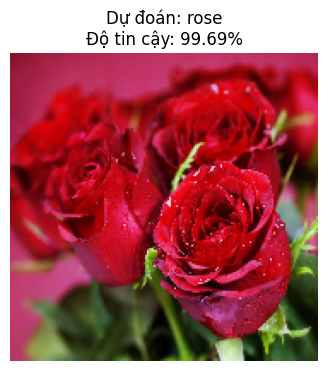

=> KẾT LUẬN: Hoa trong ảnh là rose (Độ tin cậy: 99.69%).


In [17]:
from google.colab import files
from tensorflow.keras.preprocessing import image

print("Vui lòng tải lên một hình ảnh hoa để nhận diện:")
uploaded = files.upload()

for fn in uploaded.keys():
  path = '/content/' + fn

  # Đọc và thay đổi kích thước ảnh theo chuẩn đầu vào của mô hình
  img = image.load_img(path, target_size=(img_height, img_width))
  img_array = image.img_to_array(img)
  img_array = tf.expand_dims(img_array, 0) # Thêm chiều batch để phù hợp với input (1, 180, 180, 3)

  # Đưa vào dự đoán
  predictions = model.predict(img_array)

  # Tính toán độ tin cậy bằng hàm softmax
  score = tf.nn.softmax(predictions[0])

  predicted_class = class_names[np.argmax(score)]
  confidence = 100 * np.max(score)

  # Hiển thị hình ảnh và kết quả
  plt.figure(figsize=(4, 4))
  plt.imshow(img)
  plt.axis('off')
  plt.title(f"Dự đoán: {predicted_class}\nĐộ tin cậy: {confidence:.2f}%")
  plt.show()

  print(f"=> KẾT LUẬN: Hoa trong ảnh là {predicted_class} (Độ tin cậy: {confidence:.2f}%).")


Vui lòng tải lên một hình ảnh hoa để nhận diện:


Saving Bo_Cong_Anh_Vang_1.jpg to Bo_Cong_Anh_Vang_1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


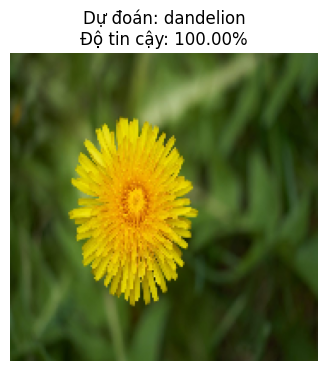

=> KẾT LUẬN: Hoa trong ảnh là dandelion (Độ tin cậy: 100.00%).


In [20]:
from google.colab import files
from tensorflow.keras.preprocessing import image

print("Vui lòng tải lên một hình ảnh hoa để nhận diện:")
uploaded = files.upload()

for fn in uploaded.keys():
  path = '/content/' + fn

  # Đọc và thay đổi kích thước ảnh theo chuẩn đầu vào của mô hình
  img = image.load_img(path, target_size=(img_height, img_width))
  img_array = image.img_to_array(img)
  img_array = tf.expand_dims(img_array, 0) # Thêm chiều batch để phù hợp với input (1, 180, 180, 3)

  # Đưa vào dự đoán
  predictions = model.predict(img_array)

  # Tính toán độ tin cậy bằng hàm softmax
  score = tf.nn.softmax(predictions[0])

  predicted_class = class_names[np.argmax(score)]
  confidence = 100 * np.max(score)

  # Hiển thị hình ảnh và kết quả
  plt.figure(figsize=(4, 4))
  plt.imshow(img)
  plt.axis('off')
  plt.title(f"Dự đoán: {predicted_class}\nĐộ tin cậy: {confidence:.2f}%")
  plt.show()

  print(f"=> KẾT LUẬN: Hoa trong ảnh là {predicted_class} (Độ tin cậy: {confidence:.2f}%).")


Vui lòng tải lên một hình ảnh hoa để nhận diện:


Saving Sunflower.jpeg to Sunflower.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


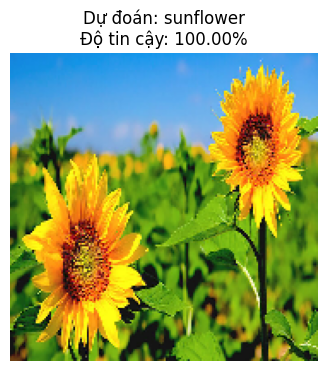

=> KẾT LUẬN: Hoa trong ảnh là sunflower (Độ tin cậy: 100.00%).


In [21]:
from google.colab import files
from tensorflow.keras.preprocessing import image

print("Vui lòng tải lên một hình ảnh hoa để nhận diện:")
uploaded = files.upload()

for fn in uploaded.keys():
  path = '/content/' + fn

  # Đọc và thay đổi kích thước ảnh theo chuẩn đầu vào của mô hình
  img = image.load_img(path, target_size=(img_height, img_width))
  img_array = image.img_to_array(img)
  img_array = tf.expand_dims(img_array, 0) # Thêm chiều batch để phù hợp với input (1, 180, 180, 3)

  # Đưa vào dự đoán
  predictions = model.predict(img_array)

  # Tính toán độ tin cậy bằng hàm softmax
  score = tf.nn.softmax(predictions[0])

  predicted_class = class_names[np.argmax(score)]
  confidence = 100 * np.max(score)

  # Hiển thị hình ảnh và kết quả
  plt.figure(figsize=(4, 4))
  plt.imshow(img)
  plt.axis('off')
  plt.title(f"Dự đoán: {predicted_class}\nĐộ tin cậy: {confidence:.2f}%")
  plt.show()

  print(f"=> KẾT LUẬN: Hoa trong ảnh là {predicted_class} (Độ tin cậy: {confidence:.2f}%).")


Vui lòng tải lên một hình ảnh hoa để nhận diện:


Saving Tulip.jpg to Tulip.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


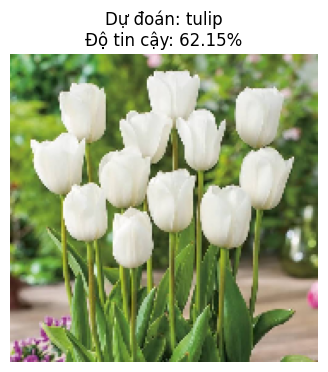

=> KẾT LUẬN: Hoa trong ảnh là tulip (Độ tin cậy: 62.15%).


In [22]:
from google.colab import files
from tensorflow.keras.preprocessing import image

print("Vui lòng tải lên một hình ảnh hoa để nhận diện:")
uploaded = files.upload()

for fn in uploaded.keys():
  path = '/content/' + fn

  # Đọc và thay đổi kích thước ảnh theo chuẩn đầu vào của mô hình
  img = image.load_img(path, target_size=(img_height, img_width))
  img_array = image.img_to_array(img)
  img_array = tf.expand_dims(img_array, 0) # Thêm chiều batch để phù hợp với input (1, 180, 180, 3)

  # Đưa vào dự đoán
  predictions = model.predict(img_array)

  # Tính toán độ tin cậy bằng hàm softmax
  score = tf.nn.softmax(predictions[0])

  predicted_class = class_names[np.argmax(score)]
  confidence = 100 * np.max(score)

  # Hiển thị hình ảnh và kết quả
  plt.figure(figsize=(4, 4))
  plt.imshow(img)
  plt.axis('off')
  plt.title(f"Dự đoán: {predicted_class}\nĐộ tin cậy: {confidence:.2f}%")
  plt.show()

  print(f"=> KẾT LUẬN: Hoa trong ảnh là {predicted_class} (Độ tin cậy: {confidence:.2f}%).")


Vui lòng tải lên một hình ảnh hoa để nhận diện:


Saving Hoa_Hồng.jpg to Hoa_Hồng (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


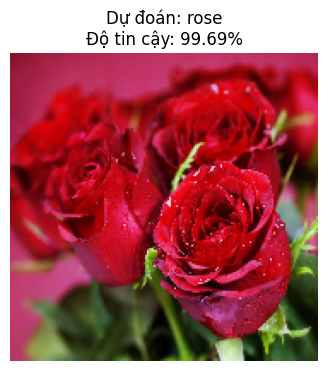

=> KẾT LUẬN: Hoa trong ảnh là rose (Độ tin cậy: 99.69%).


In [23]:
from google.colab import files
from tensorflow.keras.preprocessing import image

print("Vui lòng tải lên một hình ảnh hoa để nhận diện:")
uploaded = files.upload()

for fn in uploaded.keys():
  path = '/content/' + fn

  # Đọc và thay đổi kích thước ảnh theo chuẩn đầu vào của mô hình
  img = image.load_img(path, target_size=(img_height, img_width))
  img_array = image.img_to_array(img)
  img_array = tf.expand_dims(img_array, 0) # Thêm chiều batch để phù hợp với input (1, 180, 180, 3)

  # Đưa vào dự đoán
  predictions = model.predict(img_array)

  # Tính toán độ tin cậy bằng hàm softmax
  score = tf.nn.softmax(predictions[0])

  predicted_class = class_names[np.argmax(score)]
  confidence = 100 * np.max(score)

  # Hiển thị hình ảnh và kết quả
  plt.figure(figsize=(4, 4))
  plt.imshow(img)
  plt.axis('off')
  plt.title(f"Dự đoán: {predicted_class}\nĐộ tin cậy: {confidence:.2f}%")
  plt.show()

  print(f"=> KẾT LUẬN: Hoa trong ảnh là {predicted_class} (Độ tin cậy: {confidence:.2f}%).")
